In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
dataset=pd.read_csv("AmesHousing.csv")
x=dataset[["Gr Liv Area","Overall Qual","Bedroom AbvGr","Year Built"]].values
y=dataset["SalePrice"].values
print(x.shape)

(2930, 4)


x_mean: [1499.69044369    6.09488055    2.85426621 1971.35631399]
x_std : [505.4226158    1.41078527   0.82758988  30.24019886]
x_new (raw): [1629.    5.    3. 1997.]
x_new_norm : [ 0.82762845 -0.94321053 -0.94539137  1.2289023 ]
w: [38923.41864945 33524.90370473 -9936.8293073  14631.67557013]
b: 180796.0600682594


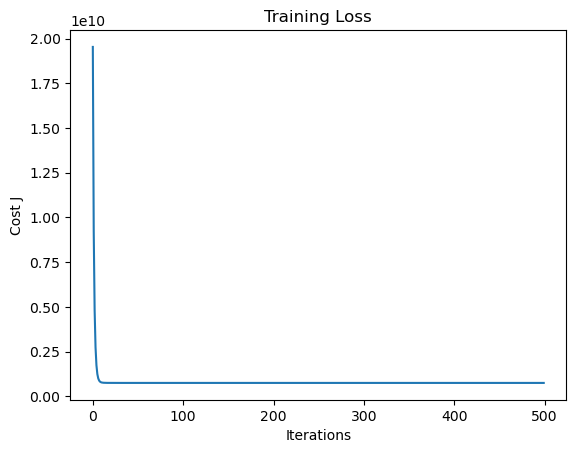

In [62]:
x_mean = x.mean(axis=0)
x_std  = x.std(axis=0)

x = (x - x_mean) / x_std


w=np.zeros(x.shape[1])
b=0
m=x.shape[0]
alpha=0.3
J_wb=[]



num_iter=500

for i in range(num_iter):
    y_hat=np.dot(x,w)+b
    error=y_hat-y

    gradient_w=(1/m)*np.dot(x.T,error)
    gradient_b=(1/m)*error.sum()

    w=w-alpha*gradient_w
    b=b-alpha*gradient_b

    J=(1/(2*m))*(np.sum(error**2))

    J_wb.append(J)

print("x_mean:", x_mean)
print("x_std :", x_std)

print("x_new (raw):", x_new)
print("x_new_norm :", x_new_norm)

print("w:", w)
print("b:", b)


plt.plot(J_wb)
plt.xlabel("Iterations")
plt.ylabel("Cost J")
plt.title("Training Loss")
plt.show()
    

In [63]:
gr_liv_area = float(input("Gr Liv Area: "))
overall_qual = float(input("Overall Qual: "))
bedroom_abvgr = float(input("Bedroom AbvGr: "))
year_built = float(input("Year Built: "))

x_new = np.array([gr_liv_area, overall_qual, bedroom_abvgr, year_built])

x_new_norm = (x_new - x_mean) / x_std

y_pred = np.dot(x_new_norm, w) + b

print(f"Predicted House Price: ₹{y_pred:,.2f}")


Gr Liv Area:  1629
Overall Qual:  5
Bedroom AbvGr:  3
Year Built:  1997


Predicted House Price: ₹175,394.27


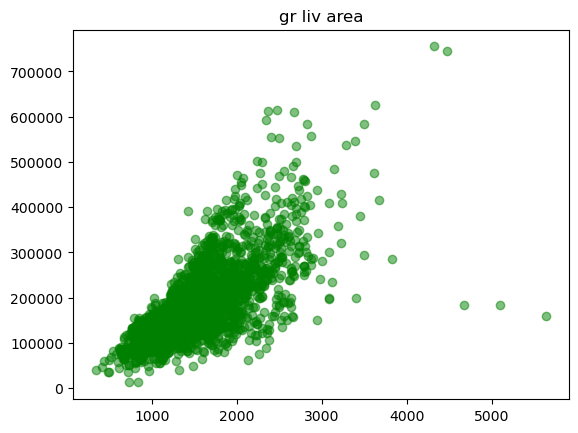

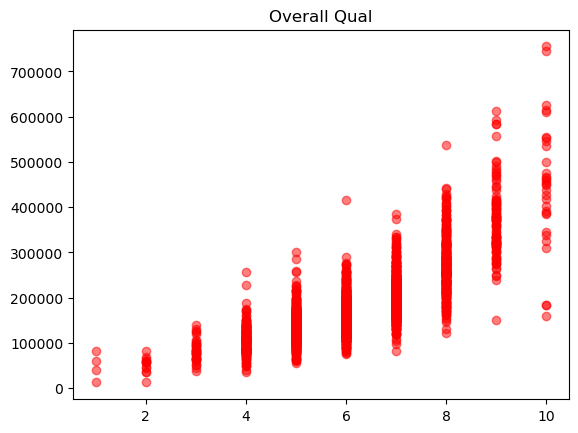

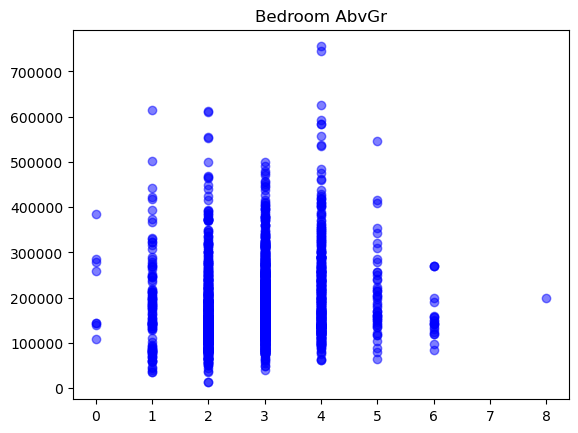

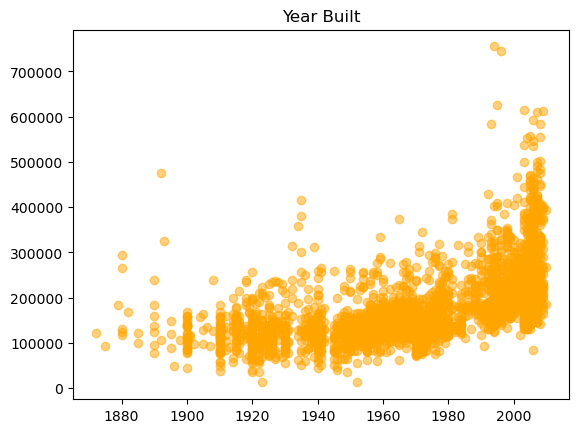

In [64]:
plt.figure()
plt.plot(dataset["Gr Liv Area"],y,color="green",linestyle="none",marker="o",alpha=0.5)
plt.title("gr liv area")
plt.show()

plt.figure()
plt.plot(dataset["Overall Qual"],y,color="red",linestyle="none",marker="o",alpha=0.5)
plt.title("Overall Qual")
plt.show()

plt.figure()
plt.plot(dataset["Bedroom AbvGr"],y,color="blue",linestyle="none",marker="o",alpha=0.5)
plt.title("Bedroom AbvGr")
plt.show()

plt.figure()
plt.plot(dataset["Year Built"],y,color="orange",linestyle="none",marker="o",alpha=0.5)
plt.title("Year Built")
plt.show()